In [1]:
import matplotlib
import matplotlib.pyplot as plt

# plt.rcParams['figure.figsize'] = [3.375, 2.8]
# plt.rcParams['figure.figsize'] = [7.1014, 2.8]
plt.rcParams['figure.figsize'] = [10, 6]

# plt.rcParams['figure.dpi'] = 200
# %config InlineBackend.figure_format = 'retina'

In [2]:
from __future__ import division, print_function
import bilby
from gwpy.timeseries import TimeSeries
import math
from bilby.gw.conversion import component_masses_to_chirp_mass, component_masses_to_symmetric_mass_ratio, luminosity_distance_to_redshift, chirp_mass_and_mass_ratio_to_component_masses
from bilby.core import utils
import numpy as np
from gwosc import datasets
from astropy import constants as const
import sys
import argparse
import configparser
import os
import errno
import json
import datetime
import scipy.signal.windows as windows
import matplotlib.pyplot as plt
from bilby.core.utils import infft

"""get current time"""
start = datetime.datetime.now()

"""constants"""
Mo = const.M_sun.value #solar mass [kg]
G = const.G.value #Newton constant [m^3 kg^-1 s^2]
c = const.c.value #light speed [m s^-1]
pc = const.pc.value #1pc [m]

"""get ringdown waveform from config file"""
def get_ringdown_waveform_from_config(config_file_path):

    config_path = config_file_path
    config_ini = configparser.ConfigParser()
    config_ini.read(config_path)

    config_setting = config_ini['setting']
    config_injection = config_ini['injection_parameters']
    config_wf_args = config_ini['waveform_arguments']
    config_others = config_ini['other_parameters']

    """set the event to be analyzed"""
    event_name = config_setting['event_name']
    outdir_path = config_setting['outdir_path']
    outdir = outdir_path + 'outdir_' + event_name
    label = event_name
    logger = bilby.core.utils.logger
    # bilby.core.utils.setup_logger(outdir=outdir, label=label)

    """output to .log file"""
    comment = config_setting['comment']
    bilby.core.utils.logger.info(comment.replace('_', ' '))
    bilby.core.utils.logger.info('event_name : '+event_name)

    one_mode=False
    mode_number = config_setting['mode_number']
    if mode_number=='one_mode':
        one_mode=True
    bilby.core.utils.logger.info('mode_number : '+mode_number)

    """parameterization"""
    parameterization = config_setting['parameterization']
    bilby.core.utils.logger.info('parameterization : '+parameterization)

    """mode number"""
    one_mode=False
    mode_number = config_setting['mode_number']
    if mode_number=='one_mode':
        one_mode=True
    bilby.core.utils.logger.info('one_mode : '+str(one_mode))

    analysis_one_mode = False
    analysis_mode_number = config_setting['analysis_mode_number']
    if analysis_mode_number=='analysis_one_mode':
        analysis_one_mode = True
    bilby.core.utils.logger.info('analysis_one_mode : '+str(analysis_one_mode))

    """parameterization"""
    parameterization = config_setting['parameterization']
    bilby.core.utils.logger.info('parameterization : '+parameterization)

    """output waveform args"""
    for key in config_wf_args.keys():
        bilby.core.utils.logger.info('{0} : {1}'.format(key, config_wf_args[key]))

    """window duration for signal roll on"""
    signal_roll_on_duration = 0.0  #default:0s
    if 'signal_roll_on_duration' in config_setting.keys():
        signal_roll_on_duration = float(config_setting['signal_roll_on_duration'])
    bilby.core.utils.logger.info('signal_roll_on_duration : {}'.format(signal_roll_on_duration))

    """waveform"""
    def toy_model_of_two_QNMs(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
    
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-17

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        tidx = time >= geocent_time

        waveform1[tidx] = A / delta_w * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = -A / delta_w * (1 + delta_w * alpha) * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        total_waveform = waveform1 + waveform2

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index

        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        total_waveform[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window

        return {"plus": plus, "cross": cross}


    def get_each_overtone(time, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time):
        """
        Returns
        -------
        dict:
            A dictionary containing "waveform1", "waveform2", and "plus" entries.
        """
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-20
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        tidx = time >= geocent_time

        waveform1[tidx] = A / delta_w * np.exp(-1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = -A * (1 + delta_w * alpha) / delta_w * np.exp(-1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        plus = (waveform1 + waveform2).real
        return {"waveform1": waveform1.real, "waveform2": waveform2.real, "plus": plus}
    
    def toy_model_of_two_QNMs_real_amp(time, A, alpha, f1, f2, tau1, tau2, phi1, phi2, geocent_time):

        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-17

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        tidx = time >= geocent_time

        real_amp_1 = np.abs(A / delta_w)
        real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

        waveform1[tidx] = real_amp_1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = real_amp_2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        total_waveform = waveform1 + waveform2

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index

        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        total_waveform[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window

        return {"plus": plus, "cross": cross}
    
    def get_each_overtone_real_amp(time, A, alpha, f1, tau1, f2, tau2, phi1, phi2, geocent_time):
        """
        Returns
        -------
        dict:
            A dictionary containing "waveform1", "waveform2", and "plus" entries.
        """
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A = A * 1e-20
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        tidx = time >= geocent_time

        real_amp_1 = np.abs(A / delta_w)
        real_amp_2 = np.abs(-A / delta_w * (1 + delta_w * alpha))

        waveform1[tidx] = real_amp_1 * np.exp(-1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = real_amp_2 * np.exp(-1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        plus = (waveform1 + waveform2).real
        return {"waveform1": waveform1.real, "waveform2": waveform2.real, "plus": plus}
    
    def damped_sinusoid(time, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A1 = A1 * 1e-19
        A2 = A2 * 1e-19

        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)
        delta_w = w2 - w1

        tidx = time >= geocent_time

        waveform1[tidx] = A1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = A2 * np.exp(1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        total_waveform = waveform1 + waveform2

        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index

        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        total_waveform[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = total_waveform.real * tukey_window
        cross = total_waveform.imag * tukey_window

        return {"plus": plus, "cross": cross}
    
    def damped_sinusoid_fdomain_Heaviside(frequency, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        A1 = A1 * 1e-19
        A2 = A2 * 1e-19

        d_positive_1 = (-1j / tau1) + (2 * (frequency + f1) * np.pi)
        d_negative_1 = (-1j / tau1) + (2 * (frequency - f1) * np.pi)
    
        d_positive_2 = (-1j / tau2) + (2 * (frequency + f2) * np.pi)
        d_negative_2 = (-1j / tau2) + (2 * (frequency - f2) * np.pi)
        
        plus = A1 * ((-1/tau1 - 1j*2*np.pi*frequency) * np.cos(phi1) + 2*np.pi*f1*np.sin(phi1)) / (d_positive_1 * d_negative_1) + A2 * ((-1/tau2 - 1j*2*np.pi*frequency) * np.cos(phi2) + 2*np.pi*f2*np.sin(phi2)) / (d_positive_2 * d_negative_2)
        cross = -A1 * (2*np.pi*f1*np.cos(phi1) + (1/tau1 + 1j*2*np.pi*frequency) * np.sin(phi1)) / (d_positive_1 * d_negative_1) - A2 * (2*np.pi*f2*np.cos(phi2) + (1/tau2 + 1j*2*np.pi*frequency) * np.sin(phi2)) / (d_positive_2 * d_negative_2)

        return {'plus': plus, 'cross': cross}
    
    def damped_sinusoid_fdomain_mirror(frequency, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        A1 = A1 * 1e-19
        A2 = A2 * 1e-19

        d_positive_1 = (1 / tau1)**2 + (2 * (frequency + f1) * np.pi)**2
        d_negative_1 = (1 / tau1)**2 + (2 * (frequency - f1) * np.pi)**2
    
        d_positive_2 = (1 / tau2)**2 + (2 * (frequency + f2) * np.pi)**2
        d_negative_2 = (1 / tau2)**2 + (2 * (frequency - f2) * np.pi)**2
        
        plus = 1 / 2**0.5 * (A1 / tau1 * (np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1) + A2 / tau2 * (np.exp(-1j * phi2) / d_positive_2 + np.exp(1j * phi2) / d_negative_2))
        cross = 1 / 2**0.5 * (-1j) * (A1 / tau1 * (- np.exp(-1j * phi1) / d_positive_1 + np.exp(1j * phi1) / d_negative_1) + A2 / tau2 * (- np.exp(-1j * phi2) / d_positive_2 + np.exp(1j * phi2) / d_negative_2))

        return {'plus': plus, 'cross': cross}
    
    def damped_sinusoid_one_mode(time, A1, f1, tau1, phi1, geocent_time):
        """
        Returns
        -------
        dict:
            A dictionary containing "plus" and "cross" entries.
        """
        waveform = np.zeros(len(time), dtype=complex)

        A1 = A1 * 1e-19
        w1 = (2*np.pi*f1 + 1j / tau1)

        tidx = time >= geocent_time

        waveform[tidx] = A1 * np.exp(1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)

        """roll on windowing"""
        dt = time[1] - time[0]
        roll_on_samples = int(signal_roll_on_duration / dt)
        start_index = np.where(tidx)[0][0]
        taper_end_index = min(start_index + roll_on_samples, len(time))
        taper_len = taper_end_index - start_index

        hann_taper = windows.hann(2 * taper_len)[:taper_len]
        waveform[start_index:taper_end_index] *= hann_taper

        """segment windowing"""
        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        plus = waveform.real * tukey_window
        cross = waveform.imag * tukey_window

        return {"plus": plus, "cross": cross}

    def get_each_overtone_as_damped_sinusoid_parameters(time, A1, A2, f1, f2, tau1, tau2, phi1, phi2, geocent_time):
        waveform1 = np.zeros(len(time), dtype=complex)
        waveform2 = np.zeros(len(time), dtype=complex)

        A1 = A1 * 1e-19
        A2 = A2 * 1e-19
        w1 = (2*np.pi*f1 + 1j / tau1)
        w2 = (2*np.pi*f2 + 1j / tau2)

        tidx = time >= geocent_time

        waveform1[tidx] = A1 * np.exp(-1j * (w1 * (time[tidx] - geocent_time)) + 1j * phi1)
        waveform2[tidx] = A2 * np.exp(-1j * (w2 * (time[tidx] - geocent_time)) + 1j * phi2)

        if one_mode:
            waveform2 = np.zeros(len(time), dtype=complex)

        tukey_window = windows.tukey(len(time), 0.1)  # Tukey window with alpha=0.1
        waveform1 *= tukey_window
        waveform2 *= tukey_window

        plus = (waveform1 + waveform2).real * tukey_window
        return {"waveform1": waveform1.real, "waveform2": waveform2.real, "plus": plus}

    """set parameters"""
    duration = float(config_others['duration'])
    sampling_frequency = float(config_others['sampling_frequency'])
    trigger_time = float(config_injection['geocent_time'])
    post_trigger_duration = float(config_others['post_trigger_duration'])
    start_time = trigger_time - duration + post_trigger_duration
    bilby.core.utils.logger.info('duration : {}'.format(duration))
    bilby.core.utils.logger.info('sampling frequency : {}'.format(sampling_frequency))
    bilby.core.utils.logger.info('trigger time : {}'.format(trigger_time))
    bilby.core.utils.logger.info('start time : {}'.format(start_time))

    config_injection['tau1'] = str(np.abs(float(config_injection['tau1']))) # make tau1 positive to be consistent with FT convention
    config_injection['tau2'] = str(np.abs(float(config_injection['tau2'])))
    """set injection parameters and waveform generator"""
    if parameterization == 'DS_window' or parameterization == 'DS_Mirror' or parameterization == 'DS_Heaviside':
        A = float(config_injection['A']) * 1e-20  # Convert to strain unit
        alpha = float(config_injection['alpha'])
        w1 = (2 * np.pi * float(config_injection['f1']) + 1j / float(config_injection['tau1']))
        w2 = (2 * np.pi * float(config_injection['f2']) + 1j / float(config_injection['tau2']))
        delta_w = w2 - w1
        A1_complex = A / delta_w
        A1 = np.abs(A1_complex) / 1e-20
        phi1_from_amp = np.angle(A1_complex)
        phi1 = float(config_injection['phi1']) + phi1_from_amp
        A2_complex = - A * (1 + alpha * delta_w) / delta_w
        A2 = np.abs(A2_complex) / 1e-20
        phi2_from_amp = np.angle(A2_complex)
        phi2 = float(config_injection['phi2']) + phi2_from_amp

        """print parameters"""
        bilby.core.utils.logger.info('')
        bilby.core.utils.logger.info('--------------------------------')
        bilby.core.utils.logger.info('A1 : {}'.format(A1))
        bilby.core.utils.logger.info('A2 : {}'.format(A2))
        bilby.core.utils.logger.info('alpha : {}'.format(alpha))
        bilby.core.utils.logger.info('w1 : {}'.format(w1))
        bilby.core.utils.logger.info('w2 : {}'.format(w2))
        bilby.core.utils.logger.info('delta_w : {}'.format(delta_w))
        bilby.core.utils.logger.info('delta_w * alpha : {}'.format(delta_w * alpha))
        bilby.core.utils.logger.info('phi1 : {}'.format(phi1))
        bilby.core.utils.logger.info('phi2 : {}'.format(phi2))
        bilby.core.utils.logger.info('--------------------------------')
        bilby.core.utils.logger.info('')
        """"""

        injection_parameters = dict(
                                    A1 = A1 * 1e-1,
                                    A2 = A2 * 1e-1,
                                    f1 = float(config_injection['f1']),
                                    f2 = float(config_injection['f2']),
                                    # deltaf = float(config_injection['f2']) - float(config_injection['f1']),
                                    tau1 = float(config_injection['tau1']),
                                    tau2 = float(config_injection['tau2']),
                                    phi1 = phi1,
                                    phi2 = phi2,
                                    ra = float(config_injection['ra']),
                                    dec = float(config_injection['dec']),
                                    psi = float(config_injection['psi']),
                                    geocent_time = float(config_injection['geocent_time']),
                                    )

        if parameterization == 'DS_window':
            waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                duration = duration,
                                sampling_frequency = sampling_frequency,
                                time_domain_source_model = damped_sinusoid,
                                start_time = start_time,
                                )
        elif parameterization == 'DS_Mirror':
            waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                duration = duration,
                                sampling_frequency = sampling_frequency,
                                frequency_domain_source_model = damped_sinusoid_fdomain_mirror,
                                start_time = start_time,
                                )
        elif parameterization == 'DS_Heaviside':
            waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                duration = duration,
                                sampling_frequency = sampling_frequency,
                                frequency_domain_source_model = damped_sinusoid_fdomain_Heaviside,
                                start_time = start_time,
                                )

        if analysis_one_mode:
            waveform_generator_one_mode_analysis = bilby.gw.waveform_generator.WaveformGenerator(
                            duration = duration,
                            sampling_frequency = sampling_frequency,
                            time_domain_source_model = damped_sinusoid_one_mode,
                            start_time = start_time,
                            )


    if parameterization == 'OT':
        injection_parameters = dict(
                                    A = float(config_injection['A']) * 1e-3,
                                    alpha = float(config_injection['alpha']),
                                    f1 = float(config_injection['f1']),
                                    f2 = float(config_injection['f2']),
                                    tau1 = float(config_injection['tau1']),
                                    tau2 = float(config_injection['tau2']),
                                    phi1 = float(config_injection['phi1']),
                                    phi2 = float(config_injection['phi2']),
                                    ra = float(config_injection['ra']),
                                    dec = float(config_injection['dec']),
                                    psi = float(config_injection['psi']),
                                    geocent_time = float(config_injection['geocent_time']),
                                    )

        waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                                duration = duration,
                                sampling_frequency = sampling_frequency,
                                time_domain_source_model = toy_model_of_two_QNMs,
                                start_time = start_time,
                                )
        
    if parameterization == 'OT_real_amp':
        delta_w = (2 * np.pi * float(config_injection['f2']) + 1j / float(config_injection['tau2'])) - (2 * np.pi * float(config_injection['f1']) + 1j / float(config_injection['tau1']))
        amp1 = float(config_injection['A']) / delta_w
        amp2 = - float(config_injection['A']) * (1 + delta_w * float(config_injection['alpha'])) / delta_w
        phi1_from_amp = np.angle(amp1)
        phi2_from_amp = np.angle(amp2)
        phi1 = float(config_injection['phi1']) + phi1_from_amp
        phi2 = float(config_injection['phi2']) + phi2_from_amp
        injection_parameters = dict(
                                    A = float(config_injection['A']) * 1e-3,
                                    alpha = float(config_injection['alpha']),
                                    f1 = float(config_injection['f1']),
                                    f2 = float(config_injection['f2']),
                                    tau1 = float(config_injection['tau1']),
                                    tau2 = float(config_injection['tau2']),
                                    phi1 = phi1,
                                    phi2 = phi2,
                                    ra = float(config_injection['ra']),
                                    dec = float(config_injection['dec']),
                                    psi = float(config_injection['psi']),
                                    geocent_time = float(config_injection['geocent_time']),
                                    )

        waveform_generator = bilby.gw.waveform_generator.WaveformGenerator(
                             duration = duration,
                             sampling_frequency = sampling_frequency,
                             time_domain_source_model = toy_model_of_two_QNMs_real_amp,
                             start_time = start_time,
                             )
    
    """set interferometers"""
    ifos = bilby.gw.detector.InterferometerList(['H1', 'L1', 'V1'])
    #ifos.set_strain_data_from_zero_noise(
    #                                sampling_frequency = sampling_frequency,
    #                                duration = duration,
    #                                start_time = start_time
    #                                )

    ifos.set_strain_data_from_power_spectral_densities(
                                    sampling_frequency = sampling_frequency,
                                    duration = duration,
                                    start_time = start_time
                                    )
    for interferometer in ifos:
        interferometer.minimum_frequency = float(config_wf_args['minimum_frequency'])
        interferometer.maximum_frequency = float(config_wf_args['maximum_frequency'])
    """inject signal"""
    ifos.inject_signal(
        waveform_generator=waveform_generator,
        parameters=injection_parameters,
        raise_error=False
    )

    """print fractional defference of the frequencies"""
    w1_real = 2 * np.pi * injection_parameters['f1']
    w1_imag = 1 / injection_parameters['tau1']
    w2_real = 2 * np.pi * float(config_injection['f2'])
    w2_imag = 1 / injection_parameters['tau2']
    w1 = w1_real + 1j * w1_imag
    w2 = w2_real + 1j * w2_imag
    delta_w = w2 - w1
    delta_w_real = delta_w.real
    delta_w_imag = delta_w.imag
    print('--------------------------------')
    print(f'mode_number = {mode_number}')
    print('w1 = {} + i*{}'.format(w1_real, w1_imag))
    print('w2 = {} + i*{}'.format(w2_real, w2_imag))
    print('delta_w = w2 - w1 = {} + i*{}'.format(delta_w.real, delta_w.imag))
    print('Re[delta_w] / Re[w1] = {}'.format(delta_w_real / w1_real))
    print('Im[delta_w] / Im[w1] = {}'.format(delta_w_imag / w1_imag))
    print('|delta_w| = {}'.format(np.abs(delta_w)))
    print('|delta_w| / |w1| = {}'.format(np.abs(delta_w) / np.abs(w1)))
    print('A / |delta_w| = {}'.format(float(config_injection['A']) / np.abs(delta_w)))
    print('--------------------------------')
    print()
    """"""

    """print SNR"""
    hf_plus_dict = {}
    hf_plus_dict['plus'] = waveform_generator.frequency_domain_strain(injection_parameters)['plus']
    hf_cross_dict = {}
    hf_cross_dict['cross'] = waveform_generator.frequency_domain_strain(injection_parameters)['cross']

    SNR_plus = np.zeros(len(ifos))
    SNR_cross = np.zeros(len(ifos))
    for num, ifo in enumerate(ifos):
        hf_det_plus = ifo.get_detector_response(hf_plus_dict, injection_parameters)
        hf_det_cross = ifo.get_detector_response(hf_cross_dict, injection_parameters)
        SNR_plus[num] = np.sqrt(ifo.optimal_snr_squared(signal=hf_det_plus).real)
        SNR_cross[num] = np.sqrt(ifo.optimal_snr_squared(signal=hf_det_cross).real)
    print('--------------------------------')
    print('SNR of only plus mode : {}'.format(SNR_plus))
    print('network SNR of only plus mode : {}'.format(np.sum(SNR_plus**2.)**0.5))
    print('SNR of only cross mode : {}'.format(SNR_cross))
    print('network SNR of only cross mode : {}'.format(np.sum(SNR_cross**2.)**0.5))
    print('--------------------------------')
    print()

    hf_det_snr = np.zeros((len(ifos), len(ifos[0].strain_data.frequency_domain_strain)), dtype=complex)
    SNR = np.zeros(len(ifos))
    for num, ifo in enumerate(ifos):
        hf_det_snr[num] = ifo.get_detector_response(waveform_generator.frequency_domain_strain(injection_parameters), injection_parameters)
        SNR[num] = np.sqrt(np.real(ifo.optimal_snr_squared(hf_det_snr[num])))
    network_SNR = np.sqrt(np.sum(SNR**2.))
    print('--------------------------------')
    print('SNR : {}'.format(SNR))
    print('network SNR : {}'.format(network_SNR))
    print('--------------------------------')
    """"""

    plot_start = trigger_time - duration/20
    plot_end = trigger_time + duration/10
    """plot waveform time domain"""
    ht_plus = waveform_generator.time_domain_strain(injection_parameters)['plus']
    ht_cross = waveform_generator.time_domain_strain(injection_parameters)['cross']
    t_array = waveform_generator.time_array
    plt.figure()
    plt.plot(t_array, ht_plus, label=r"$h_+$",)
    plt.plot(t_array, ht_cross, label=r"$h_\times$", ls='--')
    plt.legend()
    plt.xlabel("Time (s)")
    plt.ylabel("Strain")
    # plt.xlim(start_time, start_time + duration)
    plt.xlim(plot_start, plot_end)
    plt.title("Injected Strain Signal")
    plt.grid()
    plt.show()
    """"""

    """plot waveform frequency domain"""
    hf_plus = waveform_generator.frequency_domain_strain(injection_parameters)['plus']
    hf_cross = waveform_generator.frequency_domain_strain(injection_parameters)['cross']
    plt.figure()
    plt.plot(waveform_generator.frequency_array, np.abs(hf_plus), label=r"$|h_+|$")
    plt.plot(waveform_generator.frequency_array, np.abs(hf_cross), label=r"$|h_\times|$")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Strain")
    plt.title("Injected Frequency Domain Strain Signal")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    plt.legend()
    plt.show()
    """"""

    """plot overtone"""
    if parameterization == 'DS_window' or parameterization == 'DS_Mirror' or parameterization == 'DS_Heaviside':
        waveform_generator_overtone = bilby.gw.waveform_generator.WaveformGenerator(
                            duration = duration,
                            sampling_frequency = sampling_frequency,
                            time_domain_source_model = get_each_overtone_as_damped_sinusoid_parameters,
                            start_time = start_time,
                            )
        
    if parameterization == 'OT':
        waveform_generator_overtone = bilby.gw.waveform_generator.WaveformGenerator(
                            duration = duration,
                            sampling_frequency = sampling_frequency,
                            time_domain_source_model = get_each_overtone,
                            start_time = start_time,
                            )

    if parameterization == 'OT_real_amp':
        waveform_generator_overtone = bilby.gw.waveform_generator.WaveformGenerator(
                            duration = duration,
                            sampling_frequency = sampling_frequency,
                            time_domain_source_model = get_each_overtone_real_amp,
                            start_time = start_time,
                            )

    t_array = waveform_generator_overtone.time_array
    ht_overtone = waveform_generator_overtone.time_domain_strain(injection_parameters)

    plt.figure()
    plt.plot(t_array, ht_overtone['plus'].real, label=r"$h_+(t)$", color='black')
    plt.plot(t_array, ht_overtone['waveform1'].real, label=r"$h_1(t)$", ls='--', alpha=0.7)
    plt.plot(t_array, ht_overtone['waveform2'].real, label=r"$h_2(t)$", ls='--', alpha=0.7)
    plt.xlabel("Time (s)")
    plt.ylabel("Strain")
    # plt.xlim(start_time, start_time + duration)
    plt.xlim(plot_start, plot_end)
    # plt.ylim(-1e-21, 1e-21)
    plt.title("Injected Time Domain Strain Signal with Overtones")
    plt.grid()
    plt.legend()
    plt.show()
    """"""

    """plot waveform frequency domain"""
    hf_overtone_plus = waveform_generator_overtone.frequency_domain_strain(injection_parameters)['plus']
    hf_overtone_waveform1 = waveform_generator_overtone.frequency_domain_strain(injection_parameters)['waveform1']
    hf_overtone_waveform2 = waveform_generator_overtone.frequency_domain_strain(injection_parameters)['waveform2']
    plt.figure()
    plt.plot(waveform_generator.frequency_array, np.abs(hf_overtone_plus), label=r"$|h_+|$", color='black')
    plt.plot(waveform_generator.frequency_array, np.abs(hf_overtone_waveform1), label=r"$|h_1|$", ls='--', alpha=0.7)
    plt.plot(waveform_generator.frequency_array, np.abs(hf_overtone_waveform2), label=r"$|h_2|$", ls='--', alpha=0.7)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Strain")
    plt.title("Injected Frequency Domain Strain Signal")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    plt.legend()
    plt.show()
    """"""

    """plot injected waveform"""
    for ifo in ifos:
        fig, axs = plt.subplots(
                            2, 1,
                            gridspec_kw=dict(height_ratios=[1.5, 1])
                            )
        hf_det = ifo.strain_data.frequency_domain_strain
        f_array_det = ifo.frequency_array
        axs[0].loglog(f_array_det, np.abs(hf_det), label=r"$|h(f)|$")
        axs[0].set_xlabel("Frequency (Hz)")
        axs[0].set_ylabel("Strain")
        axs[0].set_title(f"Frequency Domain Strain Signal in {ifo.name} Detector")
        axs[0].grid()
        axs[0].legend()
        ht_det = ifo.strain_data.time_domain_strain
        t_array_det = ifo.time_array
        axs[1].plot(t_array_det, ht_det, label=r"$h(t)$")
        axs[1].set_xlabel("Time (s)")
        axs[1].set_ylabel("Strain")
        axs[1].set_title(f"Time Domain Strain Signal in {ifo.name} Detector")
        axs[1].grid()
        axs[1].legend()
        plt.tight_layout()
        plt.show()
    """"""

    """plot injected waveform in time domain from ifft"""
    for ifo in ifos:
        fig, axs = plt.subplots(
                            2, 1,
                            gridspec_kw=dict(height_ratios=[1.5, 1])
                            )
        # hf_det = ifo.strain_data.frequency_domain_strain
        hf_inj = waveform_generator.frequency_domain_strain(injection_parameters)
        hf_det = ifo.get_detector_response(hf_inj, injection_parameters)
        f_array_det = ifo.frequency_array
        axs[0].loglog(f_array_det, np.abs(hf_det), label=r"$|h(f)|$")
        axs[0].set_xlabel("Frequency (Hz)")
        axs[0].set_ylabel("Strain")
        axs[0].set_title(f"Frequency Domain Strain Signal in {ifo.name} Detector")
        axs[0].grid()
        axs[0].legend()
        # ht_det = infft(hf_det * np.sqrt(2. / ifo.sampling_frequency) / ifo.amplitude_spectral_density_array, ifo.sampling_frequency)
        ht_det = infft(hf_det * np.sqrt(2. / ifo.sampling_frequency), ifo.sampling_frequency)
        t_array_det = ifo.time_array
        axs[1].plot(t_array_det, ht_det, label=r"$h(t)$")
        axs[1].set_xlabel("Time (s)")
        axs[1].set_ylabel("Strain")
        axs[1].set_title(f"Time Domain Strain Signal in {ifo.name} Detector")
        axs[1].grid()
        axs[1].legend()
        plt.tight_layout()
        plt.show()
    """"""

/home/hayato.imafuku/miniconda3/envs/env/lib/python3.10/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


20:22 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.1, snr100, damped sinusoid parameterization
20:22 bilby INFO    : event_name : shiftRe_to_220_dw0.1w1_snr100_DSparam_Mirror_v2
20:22 bilby INFO    : mode_number : two_mode
20:22 bilby INFO    : parameterization : DS_Mirror
20:22 bilby INFO    : one_mode : False
20:22 bilby INFO    : analysis_one_mode : False
20:22 bilby INFO    : parameterization : DS_Mirror
20:22 bilby INFO    : minimum_frequency : 20
20:22 bilby INFO    : maximum_frequency : 512
20:22 bilby INFO    : signal_roll_on_duration : 0.0
20:22 bilby INFO    : duration : 0.5
20:22 bilby INFO    : sampling frequency : 4096.0
20:22 bilby INFO    : trigger time : 0.0
20:22 bilby INFO    : start time : -0.25
20:22 bilby INFO    : 
20:22 bilby INFO    : --------------------------------
20:22 bilby INFO    : A1 : 2.281200654005359
20:22 bilby INFO    : A2 : 2.193576170046821
20:22 bilby INFO    : alpha : 0.00029552945685847607
20:22 bilby INFO    : w1 : (1264.41434

--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*301.02689574732483
w2 = 1134.4389320257144 + i*301.02689574732483
delta_w = w2 - w1 = -129.9754142536308 + i*0.0
Re[delta_w] / Re[w1] = -0.10279495375554329
Im[delta_w] / Im[w1] = 0.0
|delta_w| = 129.9754142536308
|delta_w| / |w1| = 0.09999999999999995
A / |delta_w| = 2.281200654005359
--------------------------------

--------------------------------
SNR of only plus mode : [32.19185994 51.56028635  3.12728226]
network SNR of only plus mode : 60.865087445230856
SNR of only cross mode : [50.06831573 48.06498114 38.79610008]
network SNR of only cross mode : 79.51236402817493
--------------------------------

--------------------------------
SNR : [59.52438229 70.48904554 38.92193823]
network SNR : 100.13378502316091
--------------------------------


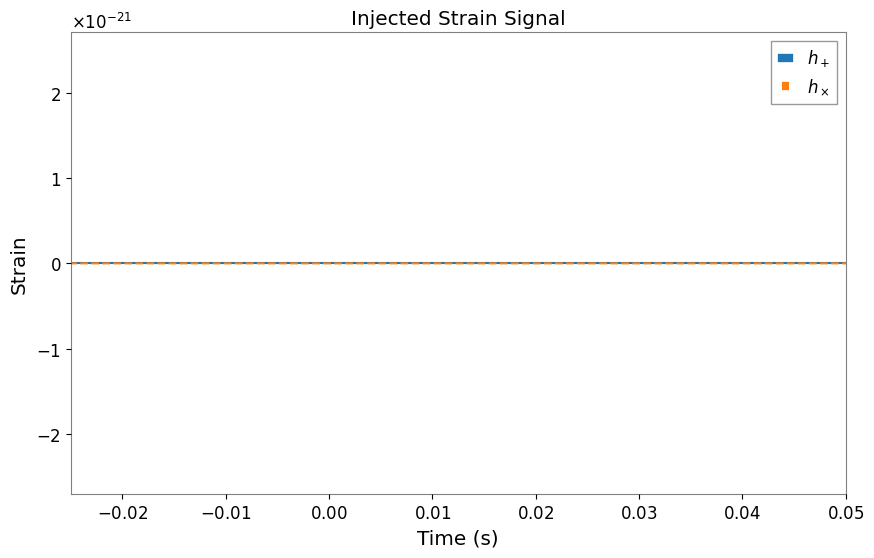

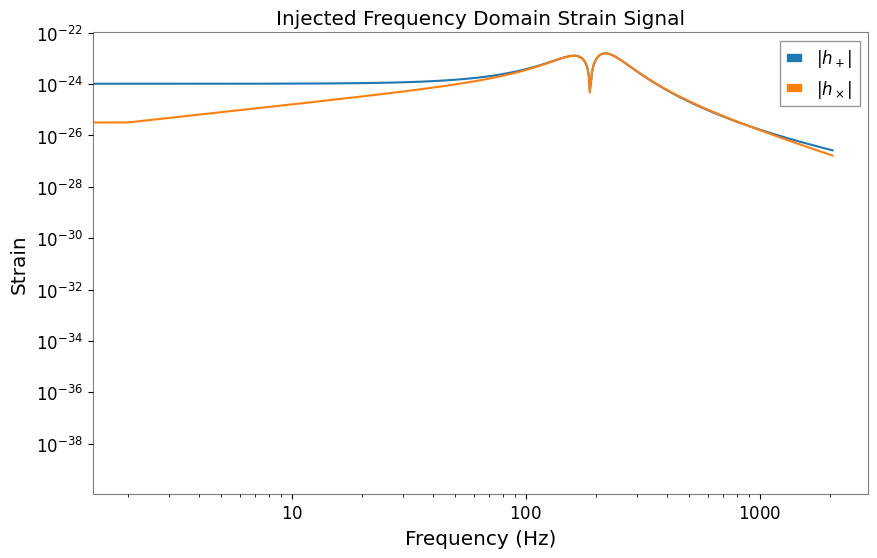

20:22 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=0.5, sampling_frequency=4096.0, start_time=-0.25, frequency_domain_source_model=None, time_domain_source_model=__main__.get_each_overtone_as_damped_sinusoid_parameters, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={})


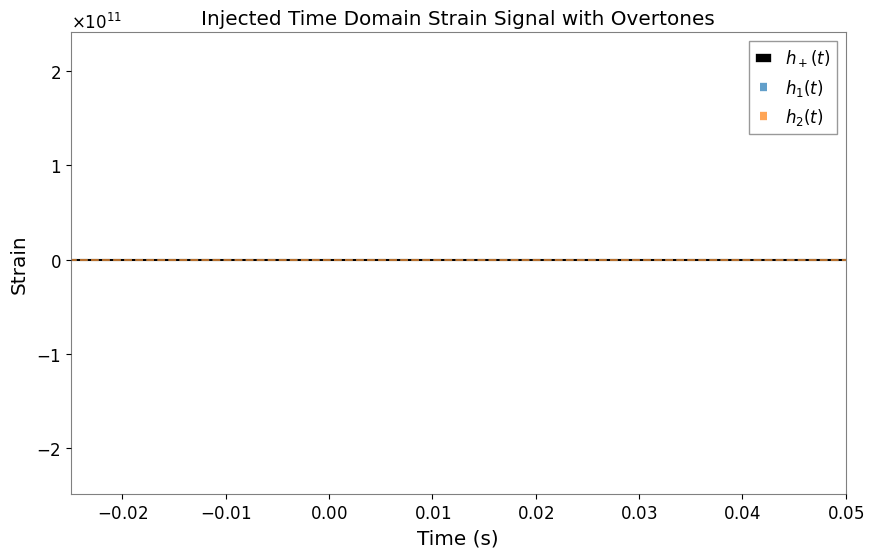

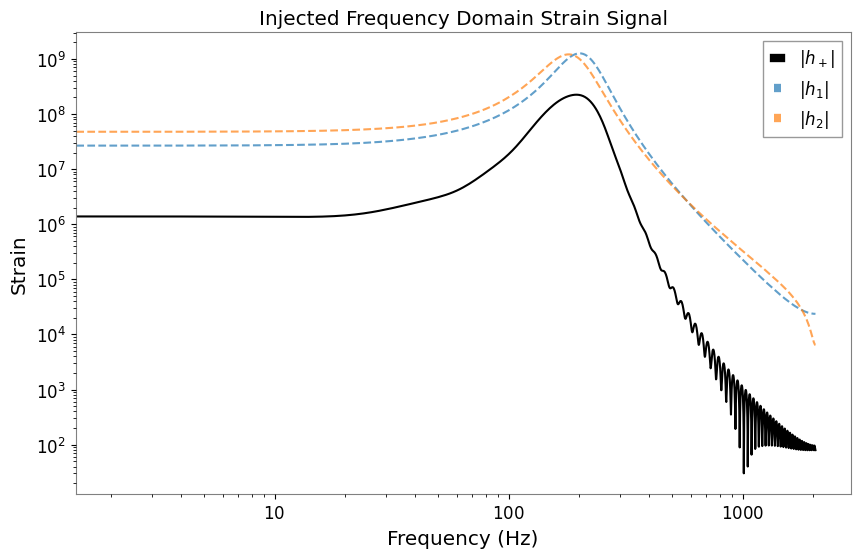

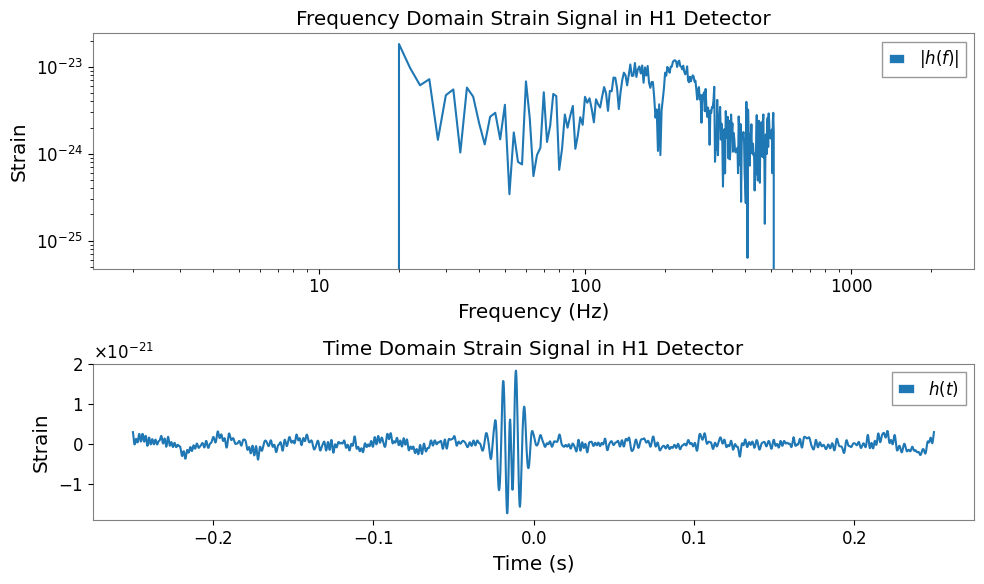

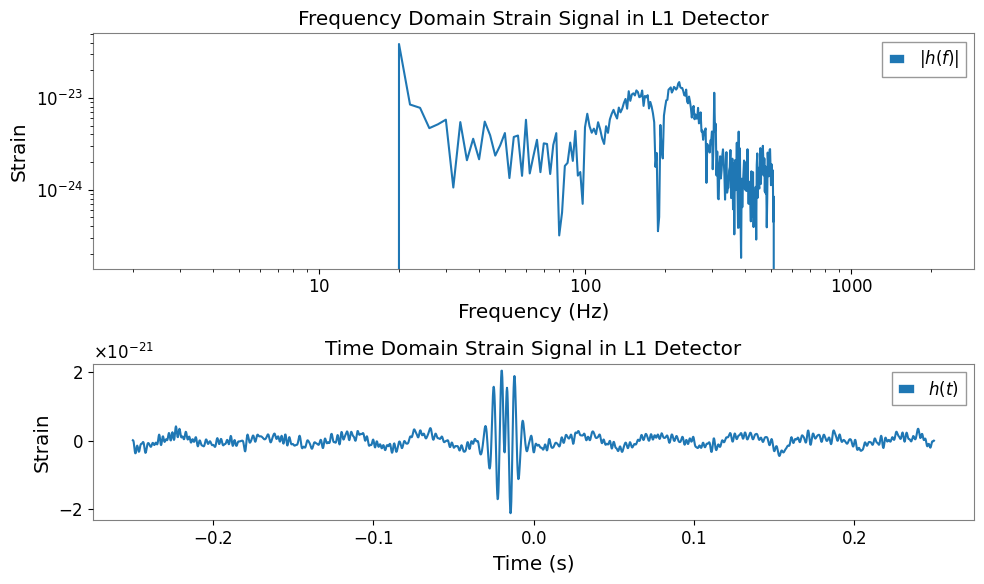

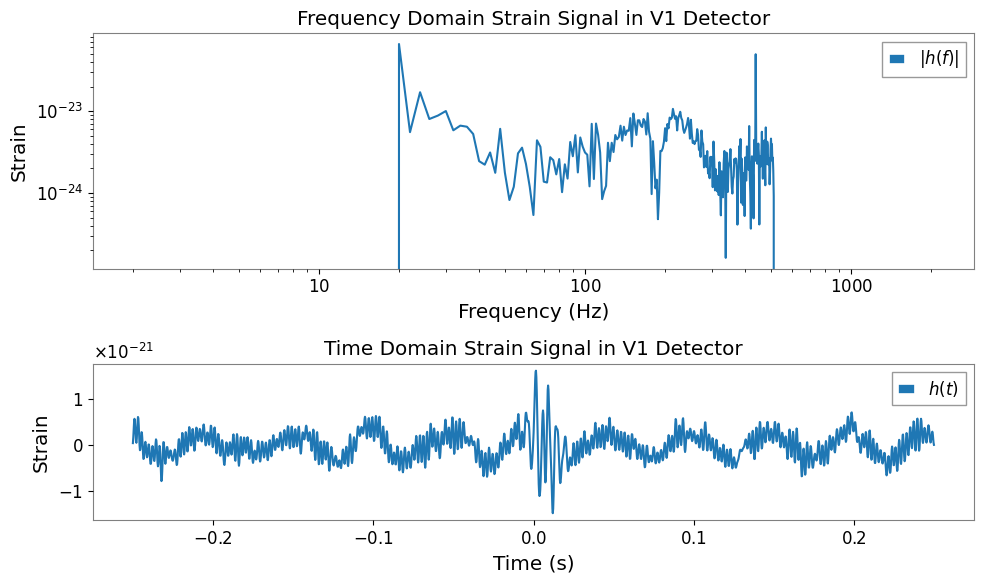

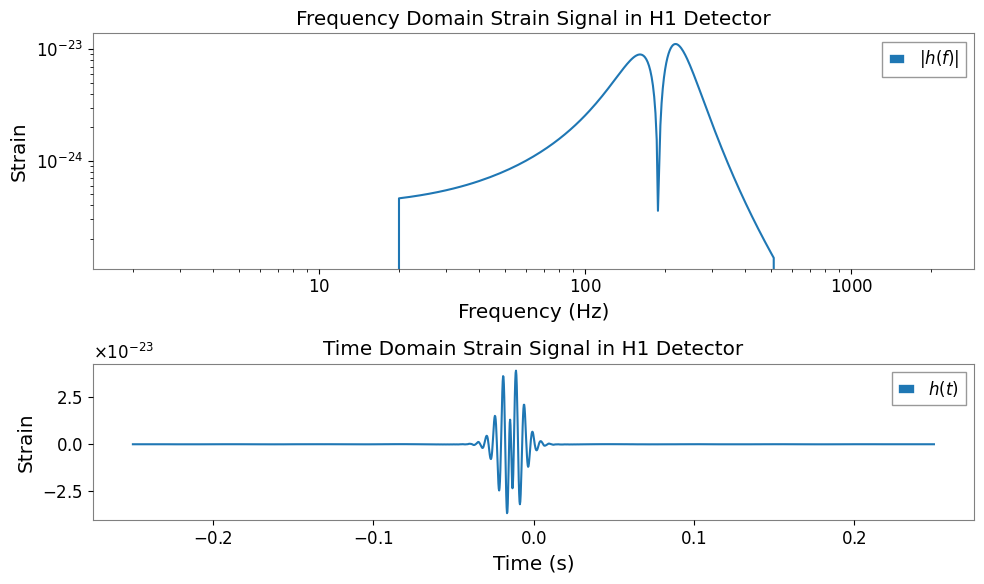

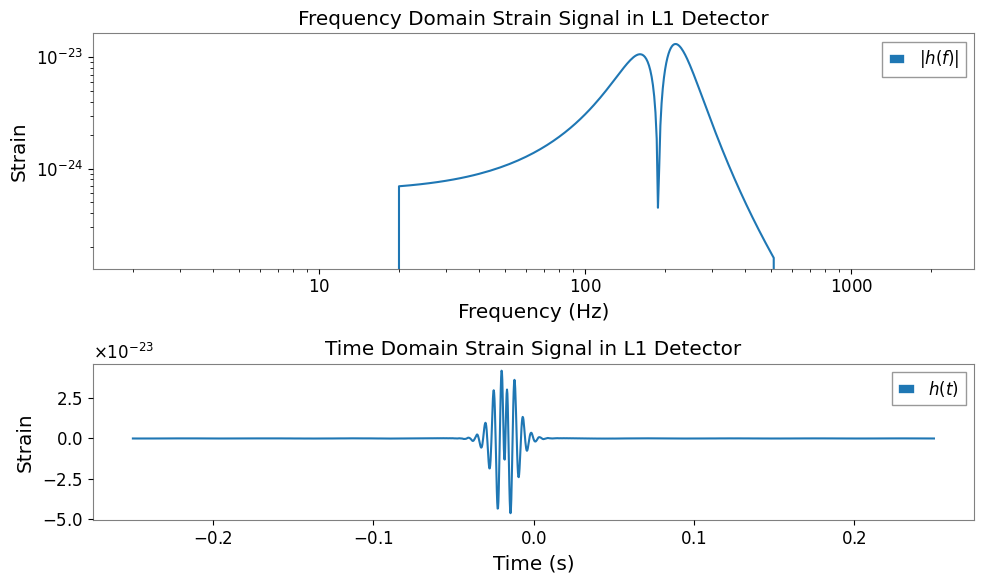

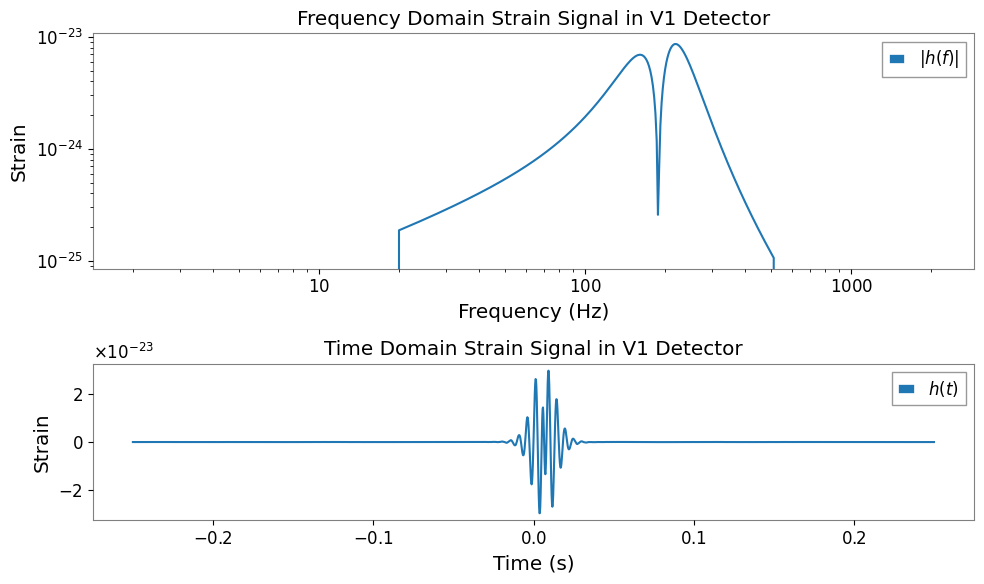

In [3]:
# config_path = './config/shiftIm_to_220_dw0.1w1_snr100_DSparam_Mirror.ini'
# config_path = './config/shiftIm_to_220_dw0.01w1_snr100_DSparam_Mirror.ini'
# config_path = './config/shiftIm_to_220_dw0.001w1_snr100_DSparam_Mirror.ini'
config_path = './config/shiftRe_to_220_dw0.1w1_snr100_DSparam_Mirror.ini'
# config_path = './config/shiftRe_to_220_dw0.01w1_snr100_DSparam_Mirror.ini'
# config_path = './config/shiftRe_to_220_dw0.001w1_snr100_DSparam_Mirror.ini'

# config_path = './config/shiftIm_to_220_dw0.1w1_snr100_OTparam_Heaviside.ini'
# config_path = './config/shiftIm_to_220_dw0.01w1_snr100_OTparam_Heaviside.ini'
# config_path = './config/shiftIm_to_220_dw0.001w1_snr100_OTparam_Heaviside.ini'
# config_path = './config/shiftRe_to_220_dw0.1w1_snr100_OTparam_Heaviside.ini'
# config_path = './config/shiftRe_to_220_dw0.01w1_snr100_OTparam_Heaviside.ini'
# config_path = './config/shiftRe_to_220_dw0.001w1_snr100_OTparam_Heaviside.ini'

get_ringdown_waveform_from_config(config_path)

21:31 bilby INFO    : shift real part of w to 220 with spin0, dw/w0.1, snr100, overtone parameterization
21:31 bilby INFO    : event_name : shiftRe_to_220_dw0.1w1_snr100_OTparam_real_amp
21:31 bilby INFO    : mode_number : two_mode
21:31 bilby INFO    : parameterization : OT_real_amp
21:31 bilby INFO    : one_mode : False
21:31 bilby INFO    : analysis_one_mode : False
21:31 bilby INFO    : minimum_frequency : 20
21:31 bilby INFO    : maximum_frequency : 512
21:31 bilby INFO    : duration : 0.5
21:31 bilby INFO    : sampling frequency : 4096.0
21:31 bilby INFO    : trigger time : 0.0
21:31 bilby INFO    : start time : -0.25
21:31 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: None
  time_domain_source_model: __main__.toy_model_of_two_QNMs_real_amp
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
21:31 bilby INFO    : Generation of mass parameters failed with message 'mass_1'
21:31 bilby INFO    : Generation of s

--------------------------------
mode_number = two_mode
w1 = 1264.4143462793452 + i*-301.02689574732483
w2 = 1134.4389320257144 + i*-301.02689574732483
delta_w = w2 - w1 = -129.9754142536308 + i*0.0
Re[delta_w] / Re[w1] = -0.10279495375554329
Im[delta_w] / Im[w1] = -0.0
|delta_w| = 129.9754142536308
|delta_w| / |w1| = 0.09999999999999995
A / |delta_w| = 2.281200654005359
--------------------------------

--------------------------------
SNR of only plus mode : [32.29963484 51.73290466  3.1075553 ]
network SNR of only plus mode : 61.06731314605789
SNR of only cross mode : [49.96463076 47.96544482 38.32139884]
network SNR of only cross mode : 79.15603472122115
--------------------------------

--------------------------------
SNR : [59.55101195 70.6194975  38.44227161]
network SNR : 100.05620770005972
--------------------------------


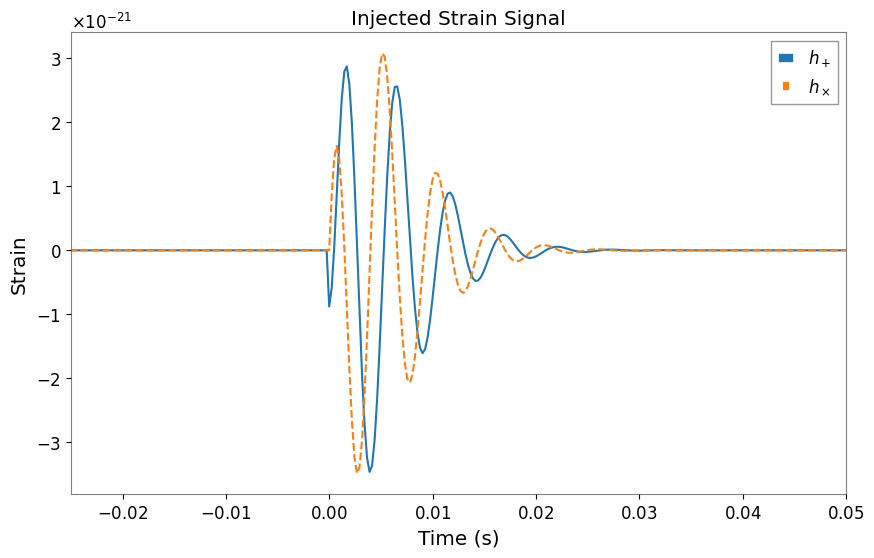

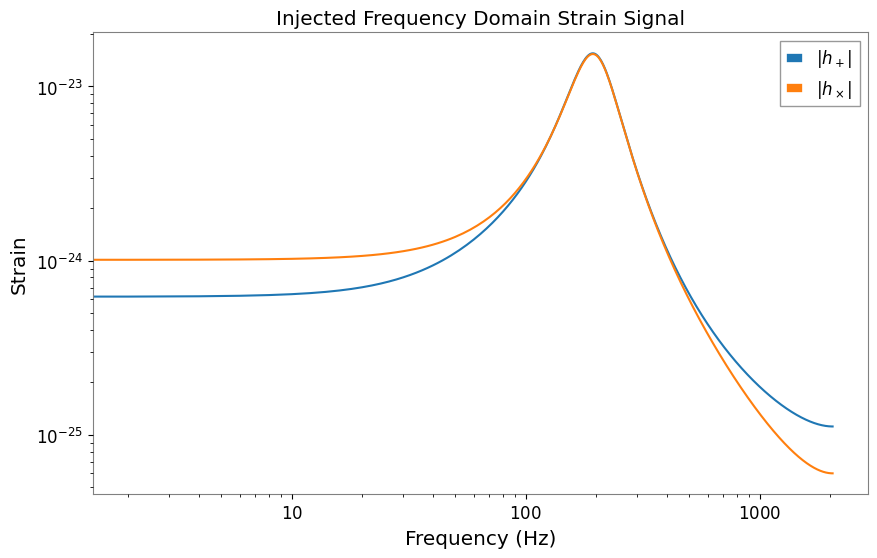

21:31 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: None
  time_domain_source_model: __main__.get_each_overtone_real_amp
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


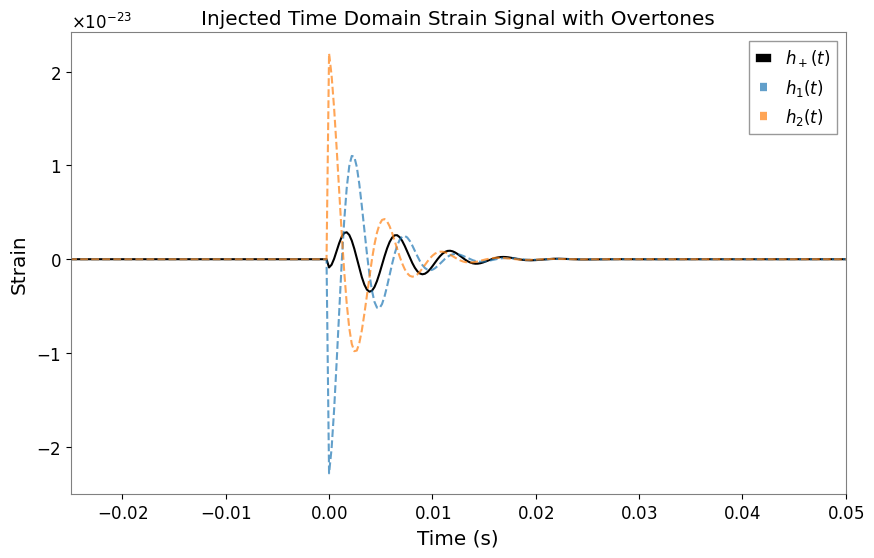

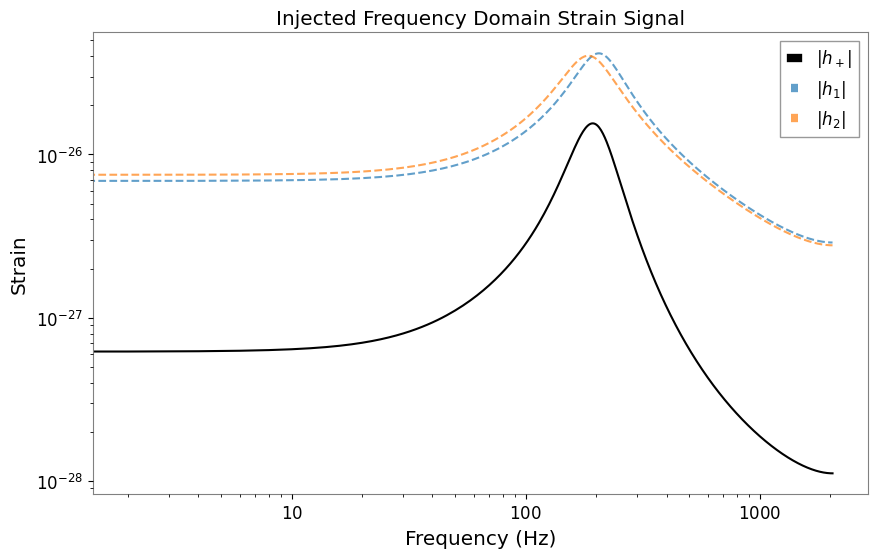

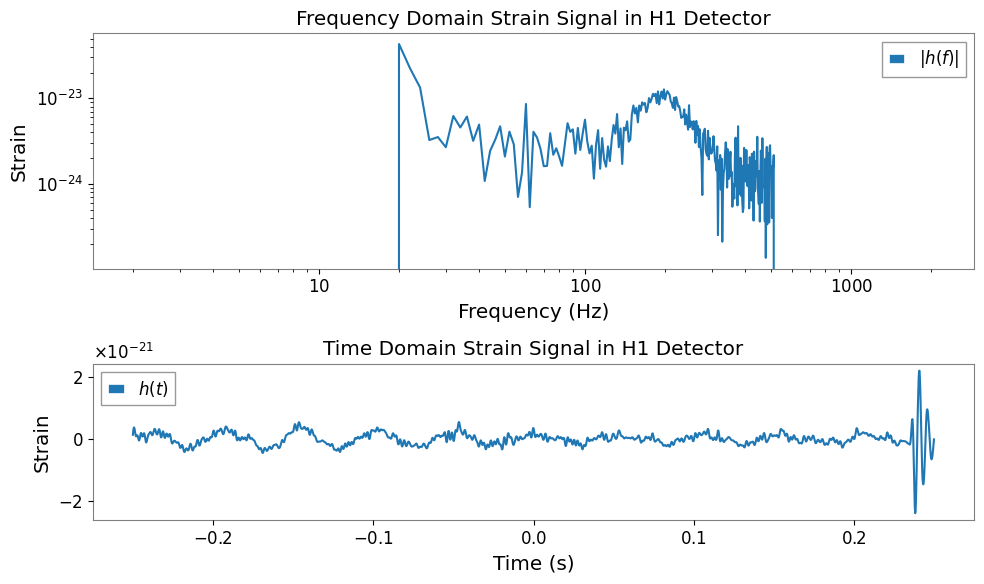

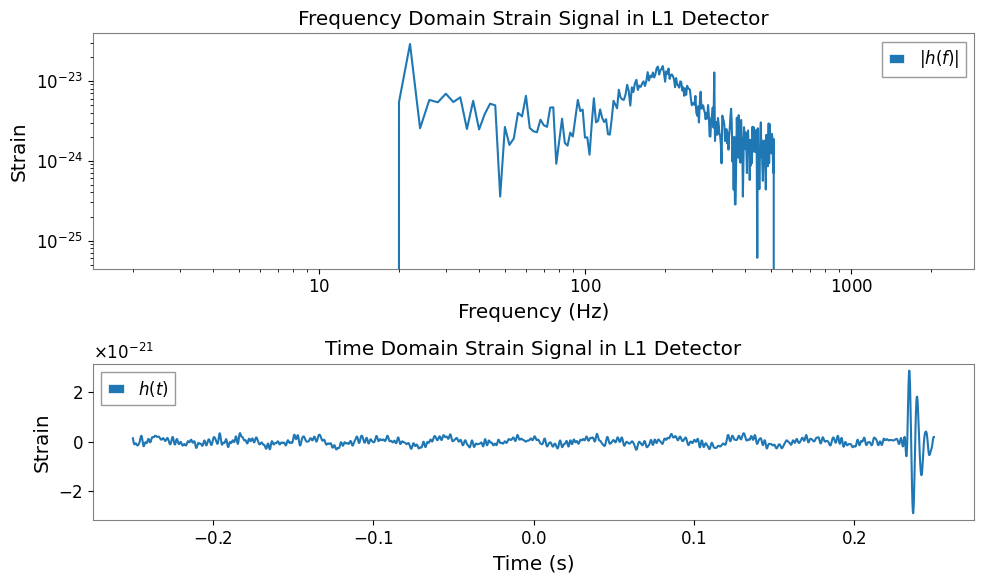

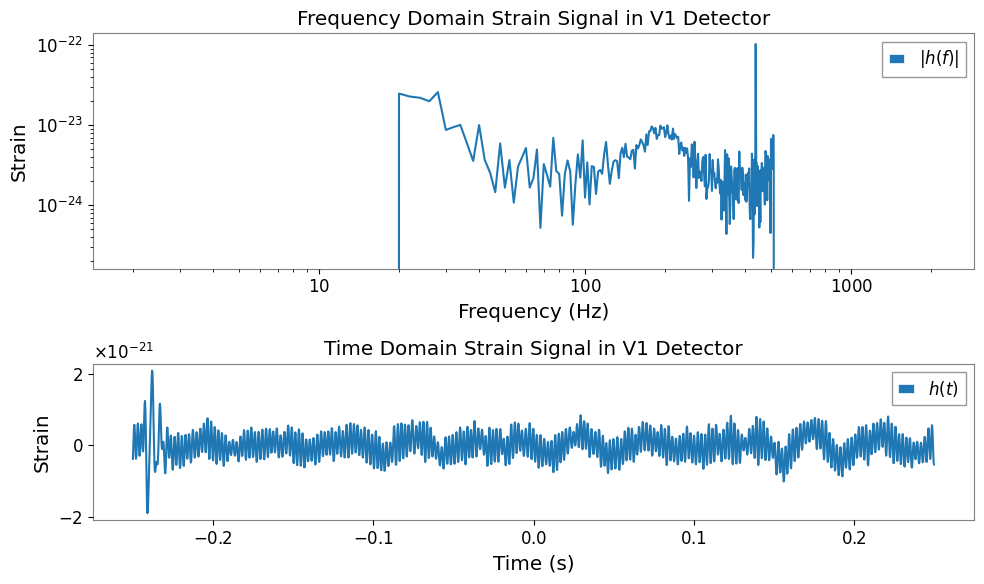

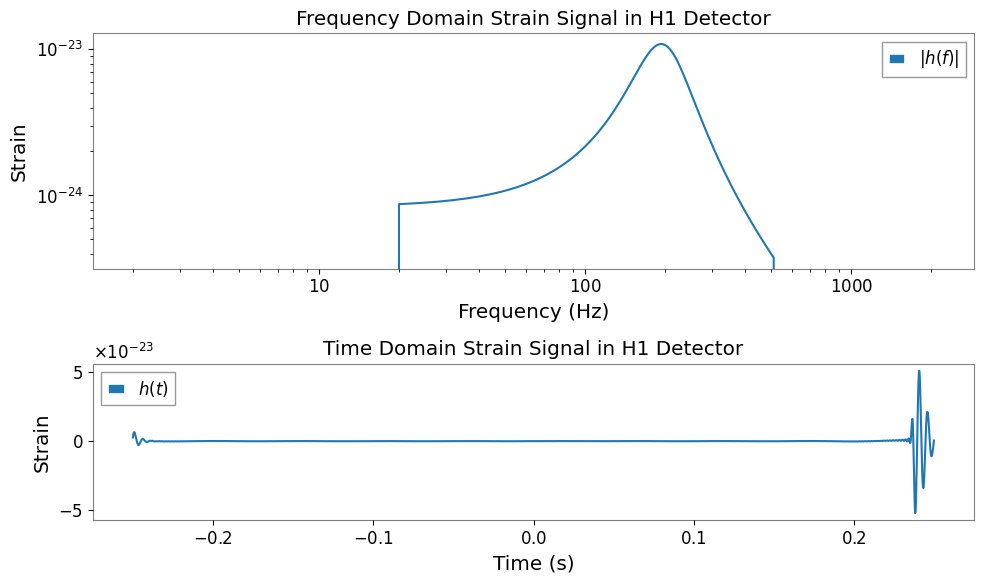

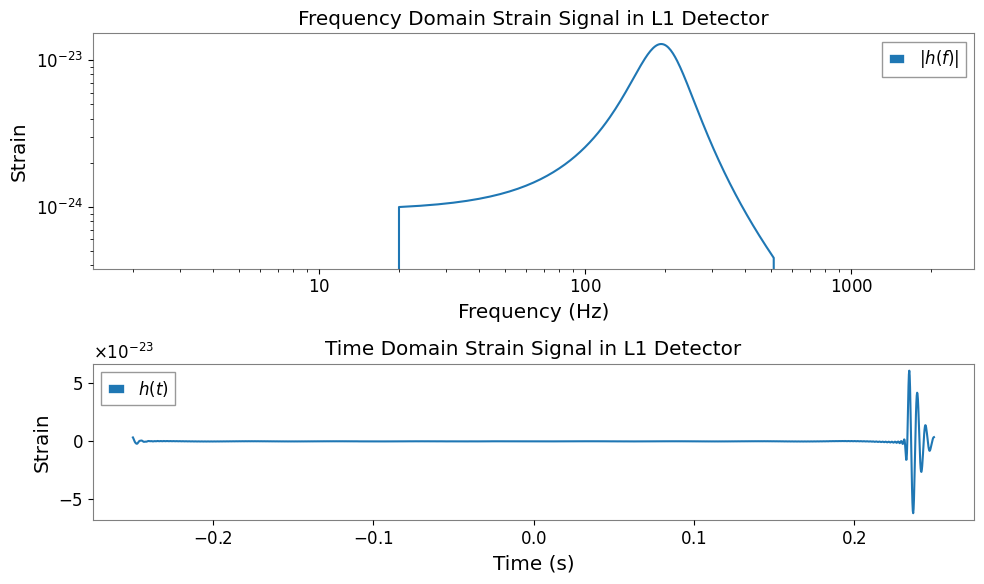

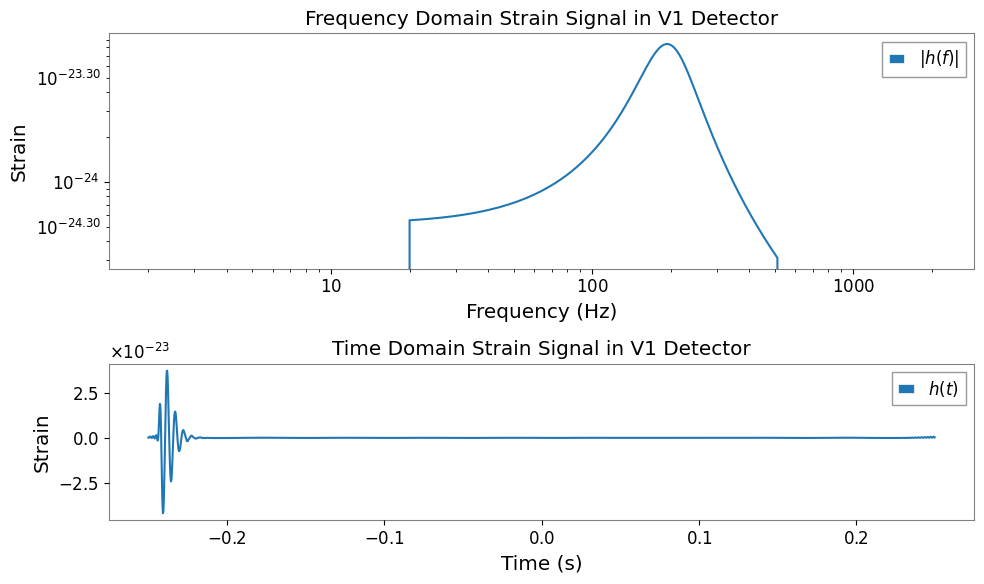

In [21]:
config_path = './config/shiftRe_to_220_dw0.1w1_snr100_OTparam_real_amp.ini'

get_ringdown_waveform_from_config(config_path)